# Unsupervised Capstone: Wine Profile Segmentation

            ## 1. Learning objectives

            - Frame an unlabeled segmentation problem
- Compare K-means and Gaussian mixtures
- Tune, visualize, and communicate limitations

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            A specialty retailer wants interpretable product-profile segments; success is compact, stable groups that experts can name and use.

            ## 4. Real-world use cases

            - Assortment planning
- Product profile discovery
- Targeted qualitative research

            ## 5. Core intuition in simple language

            Standardize measurements, establish a baseline, compare hard and soft clustering, then project the result for error analysis.

## 6. Mathematical foundation

            $$d(\mathbf{x},\mathbf{c})=\sqrt{\sum_{j=1}^{p}(x_j-c_j)^2}.$$

            **Every symbol:**

            - $\mathbf{x}$ is one observation.
- $\mathbf{c}$ is a reference point such as a centroid.
- $p$ is the number of features.
- $j$ indexes a feature.
- $d$ is Euclidean distance.

            **Why the equation is needed:** Distance turns similarity into a quantity the algorithm can compare.

            **Small numerical example:** For $\mathbf{x}=(1,2)$ and $\mathbf{c}=(4,6)$, $d=\sqrt{3^2+4^2}=5$.

            **Connection to Python:** np.linalg.norm(x - c) evaluates exactly this distance.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

The baseline is transparent NumPy K-means exposing initialization, assignment, update, and inertia.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def kmeans_scratch(features, n_clusters, max_iter=100, seed=42):
    generator = np.random.default_rng(seed)
    centroids = features[generator.choice(len(features), n_clusters, replace=False)].copy()
    for _ in range(max_iter):
        distances = np.linalg.norm(features[:, None, :] - centroids[None, :, :], axis=2)
        labels = distances.argmin(axis=1)
        new_centroids = np.vstack([
            features[labels == cluster].mean(axis=0)
            if np.any(labels == cluster) else centroids[cluster]
            for cluster in range(n_clusters)
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    inertia = float(np.sum((features - centroids[labels]) ** 2))
    return labels, centroids, inertia

tiny = np.array([[0., 0.], [0., 1.], [5., 5.], [5., 6.]])
tiny_labels, tiny_centroids, tiny_inertia = kmeans_scratch(tiny, 2)
print("Tiny centroids:", tiny_centroids.round(2).tolist(), "inertia:", round(tiny_inertia, 2))

Tiny centroids: [[0.0, 0.5], [5.0, 5.5]] inertia: 1.0


## 10. Implementation using a standard library

KMeans and GaussianMixture provide the comparison; PCA is used only for visualization.

## 11. Dataset loading and exploration

The built-in Wine dataset has 178 rows and 13 chemistry features. Cultivar labels are hidden from fitting.

## 12. Data preprocessing

There are no missing values. Standardization prevents high-range measurements from dominating distance.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Dataset: (178, 14) missing: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0


,model,silhouette,teaching ARI
0,K-means,0.285,0.897
1,Gaussian mixture,0.285,0.897


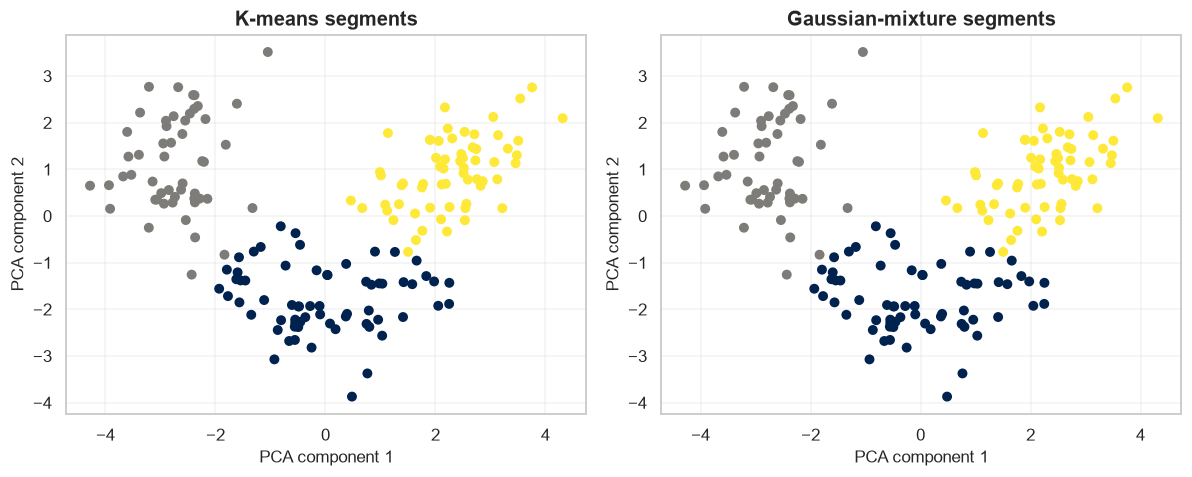

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

wine = load_wine(as_frame=True)
frame = wine.frame.copy()
print("Dataset:", frame.shape, "missing:", int(frame.isna().sum().sum()))
display(frame.head(3))
X = StandardScaler().fit_transform(wine.data)
projection = PCA(n_components=2).fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_SEED).fit(X)
gmm = GaussianMixture(n_components=3, random_state=RANDOM_SEED).fit(X)
gmm_labels = gmm.predict(X)
comparison = pd.DataFrame([
    {"model": "K-means", "silhouette": silhouette_score(X, kmeans.labels_), "teaching ARI": adjusted_rand_score(wine.target, kmeans.labels_)},
    {"model": "Gaussian mixture", "silhouette": silhouette_score(X, gmm_labels), "teaching ARI": adjusted_rand_score(wine.target, gmm_labels)},
])
display(comparison.round(3))

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, labels, title in zip(axes, [kmeans.labels_, gmm_labels], ["K-means segments", "Gaussian-mixture segments"]):
    axis.scatter(projection[:, 0], projection[:, 1], c=labels, cmap="cividis", s=30)
    axis.set(title=title, xlabel="PCA component 1", ylabel="PCA component 2")
figure.tight_layout()
plt.show()

**How to interpret the result:** The models offer alternative segmentations. PCA is lossy, so metrics use the full standardized feature space.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Tune segment count, then review stability, sizes, and domain meaning before operational use.

,k,silhouette,inertia
0,2,0.259,1658.759
1,3,0.285,1277.928
2,4,0.259,1175.352
3,5,0.232,1107.007
4,6,0.237,1046.002
5,7,0.204,981.595


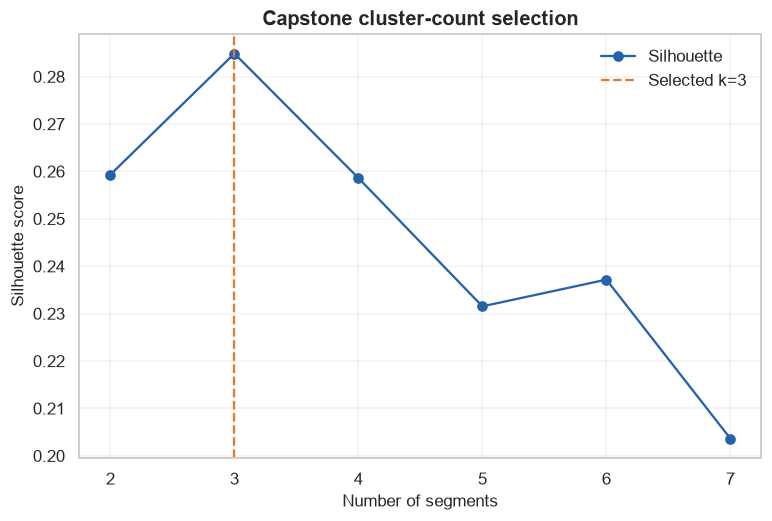

Limitation: cultivar labels are post-hoc teaching evidence; real segmentation has no answer key.


In [4]:
rows = []
for k in range(2, 8):
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED).fit(X)
    rows.append({"k": k, "silhouette": silhouette_score(X, candidate.labels_), "inertia": candidate.inertia_})
tuning = pd.DataFrame(rows)
best_k = int(tuning.loc[tuning["silhouette"].idxmax(), "k"])
display(tuning.round(3))
figure, axis = plt.subplots()
axis.plot(tuning["k"], tuning["silhouette"], marker="o", color=COURSE_COLORS["blue"], label="Silhouette")
axis.axvline(best_k, color=COURSE_COLORS["orange"], linestyle="--", label=f"Selected k={best_k}")
axis.set(title="Capstone cluster-count selection", xlabel="Number of segments", ylabel="Silhouette score")
axis.legend()
plt.show()
print("Limitation: cultivar labels are post-hoc teaching evidence; real segmentation has no answer key.")

## 18. Common mistakes

            - Calling post-hoc label agreement the optimization target
- Interpreting the PCA view as complete evidence
- Deploying segments without stability and expert review

            ## 19. Advantages and disadvantages

            **Advantages**

            - Offline end-to-end workflow
- Multiple-model comparison
- Transparent success metrics and caveats

            **Disadvantages**

            - Small benchmark dataset
- No business outcomes
- Clusters may not transfer to another population

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why are cultivar labels excluded from fitting?
2. **Mathematical/hand calculation:** If within-cluster squared distances are 4, 9, and 7, compute inertia.
3. **Coding/experimentation:** Repeat K-means over five seeds and compare partitions.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Using labels would turn the task into supervised learning.
2. Inertia is 4+9+7=20.
3. Fit five models and compare label arrays with adjusted Rand index; low agreement means instability.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - Problem framing and success criteria come before clustering
- Scaling, baselines, comparison, and tuning are part of the model
- Error analysis includes unstable points and tiny clusters
- Limitations accompany any recommendation

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)